
# Weight Quantization & Noise — Plots


In [1]:
import math, copy, os, glob, random, sys, json, torch, numpy as np, matplotlib.pyplot as plt, pandas as pd
from torch.utils.data import DataLoader, sampler, Subset
from torch import tensor
sys.path.append("../../dataset/")
from dataset import EEGDataset2DLeftRight, ToTensor
from utility import train_validate_split_5_fold_CV, sample_single_class_indices
from datetime import datetime
sys.path.append("../../src/models/")
from snn import WrapCUBASpikingCNN as WrapSNN2C

def get_device(prefer_mps = True):
    """
    Choose a device, preferring Apple MPS if available, then CUDA, else CPU.

    :param prefer_mps: Whether to prefer Apple Metal (MPS) backend when available.
    :return: Selected torch.device ("mps", "cuda" or "cpu").
    """
    if prefer_mps and hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def set_global_seed(seed):
    """
    Set global seed.

    :param seed: Random seed used for reproducibility.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def collect_weights(model, layerwise = False):
    """
    If layerwise=True, returns 1D CPU tensor of that layer's weights.

    Else returns a single concatenated 1D CPU tensor (all *.weight).

    :param model: PyTorch model whose parameters will be inspected or modified.
    :param layerwise: If True, return a dict per layer; if False, concatenate all weights into one 1D tensor.
    :return: If layerwise is True, a dict mapping parameter names to 1D CPU tensors; otherwise a single concatenated 1D CPU tensor of all weights.
    """
    parts = {
        n: p.detach().reshape(-1).cpu()
        for n, p in model.named_parameters()
        if n.endswith(".weight")
    }
    if layerwise:
        return parts
    return torch.cat(list(parts.values()))


def round_half_up(x):
    """
    Half-up rounding instead of built-in torch.round.

    :param x: Noise scaling factor; larger x gives relatively smaller Gaussian noise (sigma = mean_abs / x).
    :return: Tensor rounded in a half-up fashion with the same shape as x.
    """
    return torch.sign(x) * torch.floor(torch.abs(x) + 0.5)

def quantize_tensor_symmetric_round(w, q, A=None):
    """
    Symmetric, uniform quantization.

    For q >= 2 (even): total levels = q+1 including 0.

    :param w: Input weight tensor to be quantized or normalized.
    :param q: Number of quantization levels (power-of-two) for symmetric weight quantization.
    :param A: Symmetric quantization bound; weights are mapped into the range [-A, A].
    :return: Quantized tensor with the same shape as w.
    """
    if A is None:
        A = torch.max(w.abs())
    if A == 0:
        return w

    n_side = (q - 2) // 2
    step = A / (n_side + 1)

    # Quantize to integer multiples of step
    q_int = round_half_up(w / step)

    w.copy_(q_int * step)
    return w

@torch.no_grad()
def quantize_all_weights(model, q, unfrozen=None):
    """
    Quantize all weights.

    :param model: PyTorch model whose parameters will be inspected or modified.
    :param q: Number of quantization levels (power-of-two) for symmetric weight quantization.
    :param unfrozen: Optional list of layer name substrings that are allowed to be modified (others treated as frozen).
    :return: The same model instance, after in-place quantization of selected layers.
    """
    allow_layers = None if unfrozen is None else set(unfrozen)
    for name, p in model.named_parameters():
        if not name.endswith(".weight"):
            continue
        if name == "snn.conv1.psp_func.weight":
            A = 0.3330
        elif name == "snn.conv2.psp_func.weight":
            A = 0.0417
        elif name == "snn.conv3.psp_func.weight":
            A = 0.0295
        elif name == "snn.temp_conv1.psp_func_list.0.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.1.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.2.weight":
            A = 0.0625
        elif name == "snn.rec1.rec_func.weight":
            A = 0.0625
        elif name == "snn.fc1.psp_func.weight":
            A = 0.0625
        elif name == "snn.fc2.weight":
            A = 0.0625
        else:
            A = None
            print(f"Warning: No A value found for layer {name}, using max abs value.")

        parts = name.split(".")
        if len(parts) < 3:
            continue
        _, layer_name, *rest = parts

        if (allow_layers is not None) and (layer_name not in allow_layers):
            continue  # frozen -> skip
        # print (f"Quantizing layer {layer_name} weights")
        quantize_tensor_symmetric_round(p.data, q, A)
    return model

@torch.no_grad
def add_gaussian_noise_levelwise(model, x=1.0, q=2, seed=None, unfrozen=None):
    """
    Add gaussian noise levelwise.

    :param model: PyTorch model whose parameters will be inspected or modified.
    :param x: Noise scaling factor; larger x gives relatively smaller Gaussian noise (sigma = mean_abs / x).
    :param q: Number of quantization levels (power-of-two) for symmetric weight quantization.
    :param seed: Random seed used for reproducibility.
    :param unfrozen: Optional list of layer name substrings that are allowed to be modified (others treated as frozen).
    :return: Dictionary mapping parameter names to dictionaries with keys 'mu', 'sigma' and 'post' describing the applied Gaussian noise.
    """
    if seed is not None:
        set_global_seed(seed)

    allow_layers = None if unfrozen is None else set(unfrozen)
    cache = {}

    for name, p in model.named_parameters():
        if not name.endswith(".weight"):
            continue
        if name == "snn.conv1.psp_func.weight":
            A = 0.3330
        elif name == "snn.conv2.psp_func.weight":
            A = 0.0417
        elif name == "snn.conv3.psp_func.weight":
            A = 0.0295
        elif name == "snn.temp_conv1.psp_func_list.0.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.1.weight":
            A = 0.0625
        elif name == "snn.temp_conv1.psp_func_list.2.weight":
            A = 0.0625
        elif name == "snn.rec1.rec_func.weight":
            A = 0.0625
        elif name == "snn.fc1.psp_func.weight":
            A = 0.0625
        elif name == "snn.fc2.weight":
            A = 0.0625
        else:
            A = None
            print(f"Warning: No A value found for layer {name}, using max abs value.")

        parts = name.split(".")
        if len(parts) < 3:
            continue
        _, layer_name, *rest = parts

        if (allow_layers is not None) and (layer_name not in allow_layers):
            continue  # frozen -> skip

        w = p.data
        nz = p.detach().ne(0)
        # mu = w.abs().max()
        mu = w.abs()[nz].mean()
        sigma = mu / float(x)
        # print(f"Adding noise to layer {layer_name} weights with mu={mu:.6f}, sigma={sigma:.6f}")
        p.add_(torch.randn_like(w) * sigma)

        if A is not None:
            p.clamp_(-A, A)
            
        cache[name] = {"mu": mu, "sigma": sigma, "post": p.detach().clone()}
    return cache

## Model and Dataset Loading

In [3]:
seed=5
set_global_seed(seed)

DATASET = EEGDataset2DLeftRight  
USE_IMAGERY = True

# Define subset of subjects for LOOCV
SUBJECT_LIST = [i + 1 for i in range(109)]
EXCLUDED = [88, 89, 92, 100, 104, 106]    # subjects to exclude
SUBJECT_LIST = [s for s in SUBJECT_LIST if s not in EXCLUDED]

ds_params = {
    "base_route": "../../dataset/eegmmidb_slice_norm/",
    "subject_id_list": SUBJECT_LIST,
    "start_ts": 0,
    "end_ts": 161,
    "window_ts": 160,
    "overlap_ts": 0,
    "use_imagery": USE_IMAGERY,
    "transform": ToTensor()
}

SPIKE_TS   = 160
BATCH_SIZE = 64
CDECAY   = 0.1
VDECAY   = 0.1
VTH      = 0.1
GRAD_WIN = 0.3
TH_AMP   = 0.01
TH_DECAY = 0.1
BASE_TH  = 0.01
PARAM_LIST = [CDECAY, VDECAY, VTH, GRAD_WIN, TH_AMP, TH_DECAY, BASE_TH]

ds2 = DATASET(**ds_params)
folds2 = train_validate_split_5_fold_CV(ds2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

subject ID: [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  90  91  93
  94  95  96  97  98  99 101 102 103 105 107 108 109]
Validation subjects 0: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Validation subjects 1: [22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42]
Validation subjects 2: [43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63]
Validation subjects 3: [64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83]
Validation subjects 4: [ 84  85  86  87  90  91  93  94  95  96  97  98  99 101 102 103 105 107
 108 109]


In [4]:
def load_fold_model_and_loaders(fold_id, ds, folds, device, param_list, 
                                batch_size=64, spike_ts=160, seed=5):
    """
    Load fold model and loaders.

    :param fold_id: Cross-validation fold index (1-based) selecting which pretrained model/split to use.
    :param ds: EEG dataset instance used to build DataLoaders.
    :param folds: List of index splits (train/validation/test) for cross-validation.
    :param device: torch.device on which computations and evaluation are performed.
    :param param_list: List of neuron parameter tuples used to configure the spiking network.
    :param batch_size: Mini-batch size used for data loading during evaluation.
    :param spike_ts: Number of discrete spike time steps provided as input to the SNN.
    :param seed: Random seed used for reproducibility.
    :return: Tuple (net, pretrain_loader, test_loader, pretrained_model_path) for the selected fold.
    """
    # This matches the outer split in pretrain_network_transfer_learning
    all_pretrain_indices, test_indices = folds[fold_id - 1]

    # --- reproduce the per-class 80/20 pretrain/val split exactly ---
    random.seed(seed)
    pretrain_indices, val_indices = [], []
    for cls in range(2):
        cls_indices = [i for i in all_pretrain_indices if ds.label[i] == cls]
        random.shuffle(cls_indices)
        n_val = int(len(cls_indices) * 0.2)
        val_indices.extend(cls_indices[:n_val])
        pretrain_indices.extend(cls_indices[n_val:])

    # optional shuffling (same as training)
    random.shuffle(pretrain_indices)
    random.shuffle(val_indices)

    # --- samplers and loaders, same pattern as training script ---
    pretrain_sampler = sampler.SubsetRandomSampler(pretrain_indices)
    pretrain_val_sampler = sampler.SubsetRandomSampler(val_indices)
    pretrain_test_sampler = sampler.SubsetRandomSampler(test_indices)

    pretrain_loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        sampler=pretrain_sampler, num_workers=4, pin_memory=True)
    val_loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        sampler=pretrain_val_sampler, num_workers=4, pin_memory=True)
    test_loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        sampler=pretrain_test_sampler, num_workers=4, pin_memory=True)

    # --- load the pretrained model for this fold ---
    pattern = (f"../../snn_experiment_results/pretrained_model_5_fold/snn_pretrained_model_with_non_selected_participants_seed_5_fold_{fold_id}_*.pth")
    matches = glob.glob(pattern)
    if not matches:
        raise FileNotFoundError(f"No pretrained model found for fold {fold_id}")
    pretrained_model_path = sorted(matches)[-1]

    net = WrapSNN2C(spike_ts=spike_ts, device=device, param_list=param_list)
    net.load_state_dict(torch.load(pretrained_model_path, map_location=device))
    net.to(device)
    net.eval()

    return net, pretrain_loader, test_loader, pretrained_model_path

## Functions

In [5]:
def test_accuracy(network, test_loader, device, n=2):
    """
    Test accuracy.

    :param network: Spiking neural network instance to be evaluated.
    :param test_loader: DataLoader that yields test/validation batches (inputs, labels).
    :param device: torch.device on which computations and evaluation are performed.
    :param n: Number of output classes (2 or 4) used when converting logits to accuracies.
    :return: Tuple (overall_accuracy, per_class_accuracy) where overall_accuracy is a scalar and per_class_accuracy is a length-n array.
    """
    with torch.no_grad():
        class_correct = np.zeros(n)
        class_total = np.zeros(n)
        for data in test_loader:
            eeg_data, label = data
            eeg_data = eeg_data.to(device)
            output = network(eeg_data)
            _, predicted = torch.max(output, 1)
            c = (predicted.to('cpu') == label).numpy()
            for i in range(label.size(0)):
                la = label[i]
                class_correct[la] += c[i]
                class_total[la] += 1.
    return class_correct.sum()/class_total.sum(), class_correct / class_total


def accuracy_vs_noise_over_seeds_test(base_model, test_loader, device, q,
                                        x_vals, seeds=range(5), unfrozen=None, n=2):
    """
    Mean ± std of overall accuracy from test_accuracy over seeds and x values.

    :param base_model: Base pretrained PyTorch model whose weights are copied and perturbed for evaluation.
    :param test_loader: DataLoader that yields test/validation batches (inputs, labels).
    :param device: torch.device on which computations and evaluation are performed.
    :param q: Number of quantization levels for symmetric weight quantization.
    :param x_vals: Iterable of noise scaling factors x to evaluate.
    :param seeds: Iterable of random seeds for averaging results over multiple noise realizations.
    :param unfrozen: Optional list of layer name substrings that are allowed to be modified (others treated as frozen).
    :param n: Number of output classes (2 or 4) used when converting logits to accuracies.
    :return: Tuple (mean, std) of overall accuracies in percent for each noise level in x_vals.
    """
    acc_mat = []  # [n_seeds, len(x_vals)]
    for seed in seeds:
        set_global_seed(int(seed))
        per_seed = []
        for x in x_vals:
            m = copy.deepcopy(base_model).to(device).eval()
            quantize_all_weights(m, q, unfrozen=unfrozen)
            add_gaussian_noise_levelwise(m, x=x, seed=seed, unfrozen=unfrozen)
            acc, _ = test_accuracy(m, test_loader, device, n=n)
            per_seed.append(float(acc)*100.0)
            del m
        acc_mat.append(per_seed)
    acc_mat = np.array(acc_mat, dtype=np.float64)
    mean = acc_mat.mean(axis=0)
    std  = acc_mat.std(axis=0)
    return mean, std

In [6]:
def compute_accuracy_grid(device, q_values, x_vals=None, seeds=range(5), batch_size=64, 
                        spike_ts=160, unfrozen_configs=None, save=False, save_path=None):
    """
    Compute mean ± std accuracy across folds for combinations of:
    - quantization levels q,
    - noise magnitudes x (optional),
    - unfrozen configurations (optional).

    It always returns a tidy DataFrame with one row per (unfrozen, q, x).

    :param device: torch.device on which computations and evaluation are performed.
    :param q_values: Iterable of quantization levels to evaluate.
    :param x_vals: None for pure quantization (no noise), or iterable of noise magnitudes.
    :param seeds: Iterable of random seeds for averaging results in the noisy case.
    :param batch_size: Mini-batch size used for data loading during evaluation.
    :param spike_ts: Number of discrete spike time steps provided as input to the SNN.
    :param unfrozen_configs: None to treat all layers as unfrozen, or dict
        {config_name: list_of_layer_substrings_or_None}.
        Use None in the dict to mean "all layers" for that config.
    :param save: If True, save the resulting DataFrame to disk.
    :param save_path: Path to the CSV file where results will be stored if save=True.
    :return: Pandas DataFrame with columns:
        - unfrozen (str): name of unfrozen configuration.
        - q (int): quantization level.
        - x (float): noise magnitude (np.nan if x_vals is None).
        - mean_acc (float): mean accuracy over folds (percent).
        - std_acc (float): std over folds (percent).
    """
    folds = folds2
    ds = ds2
    loader_fn = load_fold_model_and_loaders
    n_classes = 2

    # Normalize inputs
    q_list = list(q_values)
    if x_vals is None:
        x_list = [None]  # single "no-noise" pseudo-level
    else:
        x_list = list(x_vals)

    # Unfrozen configs
    if unfrozen_configs is None:
        configs = {"all": None}
    else:
        configs = dict(unfrozen_configs)

    rows = []
    n_folds = len(folds)

    for cfg_name, unfrozen_list in configs.items():
        for q in q_list:
            fold_means = []  # [n_folds, len(x_list)]

            for fold_id in range(1, n_folds + 1):
                # Load model and loader for this fold
                net, _, test_loader, _ = loader_fn(
                    fold_id,
                    ds,
                    folds,
                    device,
                    PARAM_LIST,
                    batch_size=batch_size,
                    spike_ts=spike_ts,
                )
                net.to(device)
                net.eval()

                if x_vals is None:
                    # Pure quantization, no noise: 1 value for this fold
                    quantize_all_weights(net, q=q, unfrozen=unfrozen_list)
                    acc, _ = test_accuracy(net, test_loader, device, n_classes)
                    # wrap into length-1 array to keep shape consistent
                    fold_means.append([float(acc) * 100.0])
                else:
                    # Quantization + noise over seeds and x
                    mean_vec, _ = accuracy_vs_noise_over_seeds_test(
                        net,
                        test_loader,
                        device,
                        q=q,
                        x_vals=x_list,
                        seeds=seeds,
                        unfrozen=unfrozen_list,
                        n=n_classes,
                    )
                    # mean_vec is already in percent
                    fold_means.append(np.asarray(mean_vec, dtype=np.float64))

            fold_means = np.stack(fold_means, axis=0)  # [n_folds, len(x_list)]
            mean_over_folds = fold_means.mean(axis=0)
            std_over_folds = fold_means.std(axis=0)

            for xi, x in enumerate(x_list):
                rows.append(
                    {
                        "unfrozen": cfg_name,
                        "q": int(q),
                        "x": float(x) if x is not None else np.nan,
                        "mean_acc": float(mean_over_folds[xi]),
                        "std_acc": float(std_over_folds[xi]),
                    }
                )

    df = pd.DataFrame(rows)

    if save and (save_path is not None):
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        df.to_csv(save_path, index=False)
        print(f"Saved accuracy summary to {save_path}")

    return df


In [7]:
def load_or_compute_csv(csv_path, compute_fn):
    """
    Load a DataFrame from csv_path if it exists, otherwise compute it.

    compute_fn must be a callable that returns a Pandas DataFrame.
    It can also take care of saving the DataFrame to csv_path if desired.

    :param csv_path: Path to the CSV file.
    :param compute_fn: Zero-argument callable that returns a DataFrame.
    :return: DataFrame loaded from disk or returned by compute_fn.
    """
    if os.path.exists(csv_path):
        print(f"Loading cached results from {csv_path}")
        return pd.read_csv(csv_path)

    print(f"{csv_path} not found, computing...")
    df = compute_fn()
    return df

In [8]:
def plot_unfrozen_vs_noise_for_q(q_select, df_unf, out_path):
    """
    Plot unfrozen vs noise for q.

    :param q_select: Description of q_select.
    :param df_unf: DataFrame with accuracy vs noise results for each unfrozen configuration.
    :param out_path: Output path for the generated figure.
    """
    df_q = df_unf[df_unf["q"] == q_select].copy()

    # noise levels for this q, ordered by increasing RSD = 1/x
    noise_levels = sorted(df_q["x"].unique(), key=lambda v: 1.0 / v)
    rsd_ticks = [100.0 / v for v in noise_levels]  # RSD in percent
    nice_ticks = [t for t in rsd_ticks if t != 10]

    fig, ax = plt.subplots(figsize=(5, 3))
    plt.rcParams.update({"font.size": 14})
    i = -1
    # Distinct markers
    markers = ["o", "s", "D", "^", "v"]
    for unfrozen_name in sorted(df_q["unfrozen"].unique()):
        if unfrozen_name == "all":
            continue  # skip the "all" config

        sub = df_q[df_q["unfrozen"] == unfrozen_name].copy()

        xs_plot, mean_y, std_y = [], [], []
        for x in noise_levels:
            row = sub[sub["x"] == x].iloc[0]
            xs_plot.append(100.0 / x)          # RSD [%]
            mean_y.append(row["mean_acc"])
            std_y.append(row["std_acc"])

        xs_plot = np.array(xs_plot)
        mean_y  = np.array(mean_y)
        std_y   = np.array(std_y)
        i += 1
        marker = markers[i % len(markers)]
        
        ax.errorbar(xs_plot, mean_y, yerr=std_y, marker=marker, markerfacecolor='none', markersize=5, linewidth=1.5, capsize=3, label=unfrozen_name)

    ax.set_xlabel(r"$\eta$ (%)")
    ax.set_xticks(nice_ticks)
    ax.set_ylabel("Accuracy (%)")
    # ax.set_ylim(35.0, 65.0)
    ax.grid(True)

    ax.legend(bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0.0)

    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    plt.savefig(out_path)
    plt.show()


## Plots


### Acc vs epochs pre-training

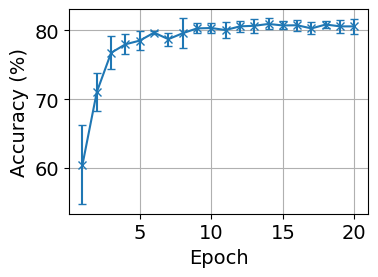

In [9]:
pattern = "../../snn_experiment_results/pretrained_model_5_fold/transfer_learning_pretraining_accuracy_seed_5_fold_{fold}_*.txt"
n_folds = 5  # adjust if needed

all_val_curves = []
epochs = None

# Create directories if missing
os.makedirs("../../results/postprocessing", exist_ok=True)
os.makedirs("../../results/figures", exist_ok=True)

for fold in range(1, n_folds + 1):
    files = sorted(glob.glob(pattern.format(fold=fold)))
    if not files:
        print(f"[WARN] no pretrain file for fold {fold}")
        continue

    df = pd.read_csv(files[-1])
    df = df[df["Phase"] == "pretrain"].copy()
    df = df.sort_values("Epoch")

    cur_epochs = df["Epoch"].to_numpy()
    cur_vals = df["Val_Accuracy"].to_numpy() * 100.0  # to %

    all_val_curves.append(cur_vals)
    epochs = cur_epochs

if not all_val_curves:
    print("[ERROR] no pretrain logs found for any fold")
else:
    val_matrix = np.stack(all_val_curves, axis=0)  # shape: (num_folds_found, num_epochs)

    mean_acc = val_matrix.mean(axis=0)
    std_acc = val_matrix.std(axis=0)

    plt.figure(figsize=(4, 3))
    plt.rcParams.update({"font.size": 14})

    df = pd.DataFrame({"epochs": epochs, "mean": mean_acc, "std": std_acc})
    df.to_csv("../../results/postprocessing/plot_baseline.csv", index=False)

    plt.errorbar(epochs, mean_acc, yerr=std_acc, marker="x", capsize=3)

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig("../../results/figures/val_acc_over_epochs.svg")
    plt.show()

### Acc vs q without noise

In [10]:
# test accuracies before quant
pattern = "../../snn_experiment_results/pretrained_model_5_fold/transfer_learning_pretraining_accuracy_seed_5_fold_{fold}_*.txt"

final_test_accs = []

for fold in range(1, 6):  # 5 folds
    files = sorted(glob.glob(pattern.format(fold=fold)))
    if not files:
        print(f"[WARN] no pretrain file for fold {fold}")
        continue

    df = pd.read_csv(files[-1])
    df = df[df["Phase"] == "pretrain"].copy()
    df = df.sort_values("Epoch")

    last_acc = df["Test_Accuracy"].iloc[-1] * 100.0  # -> %
    final_test_accs.append(last_acc)

if final_test_accs:
    mean_test = np.mean(final_test_accs)
    std_test  = np.std(final_test_accs)
    print(f"Floating-point pretrain test accuracy (last epoch): {mean_test:.2f}% ± {std_test:.2f}%")
else:
    print("[ERROR] no pretrain logs found for any fold")

Floating-point pretrain test accuracy (last epoch): 80.39% ± 2.98%


Loading cached results from ../../results/postprocessing/acc_vs_q.csv


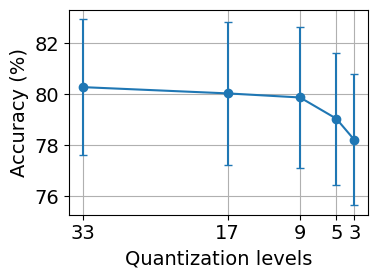

In [11]:
csv_path_2c = "../../results/postprocessing/acc_vs_q.csv"

q_values_compute = np.array([2, 4, 8, 16, 32])

# 2-class
df2 = load_or_compute_csv(
    csv_path_2c,
    lambda: compute_accuracy_grid(
        device=device,
        q_values=q_values_compute,
        x_vals=None,                 # no noise -> pure quantization
        seeds=range(5),
        batch_size=BATCH_SIZE,
        spike_ts=SPIKE_TS,
        unfrozen_configs=None,
        save=True,
        save_path=csv_path_2c,
    ),
)

# Keep only all-layers, no-noise rows and sort by q
df2 = df2[(df2["unfrozen"] == "all") & df2["x"].isna()].copy()
df2 = df2.sort_values("q")

q_values = df2["q"].values
q_values = np.array(q_values)

mean_acc_2 = df2["mean_acc"].values
std_acc_2  = df2["std_acc"].values

plt.figure(figsize=(4, 3))
plt.rcParams.update({"font.size": 14})

df = pd.DataFrame({"q_values": q_values, "mean_acc_2": mean_acc_2, "std_acc_2": std_acc_2})
df.to_csv("../../results/postprocessing/plot_acc_vs_q_no_noise.csv", index=False)

plt.errorbar(q_values + 1, mean_acc_2, yerr=std_acc_2, marker="o", capsize=3, label="2-class")

plt.xlabel("Quantization levels")
plt.xticks(q_values_compute + 1)
plt.ylabel("Accuracy (%)")
# plt.ylim(70.0, 85.0)
plt.grid(True)
plt.gca().invert_xaxis()
# plt.legend(loc="best")

plt.tight_layout()
plt.savefig("../../results/figures/acc_vs_q.svg")

In [12]:
print(mean_acc_2, std_acc_2)

[78.21375661 79.05079365 79.88148148 80.04126984 80.28783069] [2.56954576 2.5949964  2.77600972 2.8122047  2.66180501]


### Layerwise quant+noise

In [ ]:
csv_path = "../../results/postprocessing/acc_vs_noise_grid.csv"
q_values_compute = np.array([2, 4, 8, 16, 32])
# q_values_compute = np.array([2])

x_vals_compute = [1.0, 2.0, 4.0, 10.0, 20.0]

UNFROZEN_CONFIGS = {
    "all": None,          # all layers unfrozen (all weights)
    "conv1": ["conv1"],
    "conv2": ["conv2"],
    "conv3": ["conv3"],
    "tc1":   ["temp_conv1"],
    "r1":    ["rec1"],
    "fc1":   ["fc1"],
    "fc2":   ["fc2"],
}

# Compute or load
df_unf = load_or_compute_csv(
    csv_path,
    lambda: compute_accuracy_grid(
        device=device,
        q_values=q_values_compute,
        x_vals=x_vals_compute,
        seeds=range(5),
        batch_size=BATCH_SIZE,
        spike_ts=SPIKE_TS,
        unfrozen_configs=UNFROZEN_CONFIGS,
        save=True,
        save_path=csv_path,
    ),
)

plot_unfrozen_vs_noise_for_q(2, df_unf, "../../results/figures/acc_vs_noise_unfrozen_RSD_q2_no_all.svg")


### All layers acc vs noise

Loading cached results from ../../results/postprocessing/acc_vs_noise.csv
The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


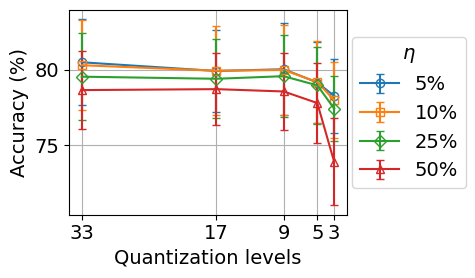

In [14]:
# run above code cell to get the df_unf dataframe

csv_path = "../../results/postprocessing/acc_vs_noise.csv"
q_values_compute = np.array([2, 4, 8, 16, 32])
# q_values_compute = np.array([2])
x_vals_compute = [1.0, 2.0, 4.0, 10.0, 20.0]
UNFROZEN_CONFIGS = {
    "all": None,          # all layers unfrozen (all weights)
    "conv1": ["conv1"],
    "conv2": ["conv2"],
    "conv3": ["conv3"],
    "tc1":   ["temp_conv1"],
    "r1":    ["rec1"],
    "fc1":   ["fc1"],
    "fc2":   ["fc2"],
}

# Compute or load
df_unf = load_or_compute_csv(
    csv_path,
    lambda: compute_accuracy_grid(
        device=device,
        q_values=q_values_compute,
        x_vals=x_vals_compute,
        seeds=range(5),
        batch_size=BATCH_SIZE,
        spike_ts=SPIKE_TS,
        unfrozen_configs=UNFROZEN_CONFIGS,
        save=True,
        save_path=csv_path,
    ),
)

classes_list  = [2] 
x_vals_plot = [2.0, 4.0, 10.0, 20.0]

# Distinct line styles for exactly 5 curves
linestyles = ["-", "--", "-.", ":", (0, (3, 5, 1, 5))]

# Distinct markers for exactly 5 curves
markers = ["o", "s", "D", "^", "v"]

figure_path = "../../results/figures/acc_vs_noise_all_layers.svg"
os.makedirs(os.path.dirname(figure_path), exist_ok=True)

# filter to "all layers" config from the big CSV
df_all = df_unf[df_unf["unfrozen"] == "all"].copy() 

q_values = sorted(df_all["q"].unique())
x_values = sorted(df_all["x"].unique())

plt.rcParams.update({"font.size": 14})
fig, ax = plt.subplots(figsize=(5, 3))

i = -1
for x in sorted(x_values, reverse=True):
    if x not in x_vals_plot:
        continue

    sub = df_all[df_all["x"] == x].copy().sort_values("q")

    q_vals = sub["q"].values
    mean_x = sub["mean_acc"].values
    std_x  = sub["std_acc"].values
    rsd    = 100.0 / x

    i += 1
    style  = linestyles[i]
    marker = markers[i]

    df = pd.DataFrame({"q_vals": q_vals, "mean_x": mean_x, "std_x": std_x})
    df.to_csv(f"../../results/postprocessing/plot_acc_vs_q_with_noise_x_{x}.csv", index=False)

    ax.errorbar(q_vals + 1, mean_x, yerr=std_x, marker=marker,
                markerfacecolor="none", markersize=6,
                linewidth=1.5, capsize=3, label=f"{rsd:.0f}%")

ax.set_xlabel("Quantization levels")
ax.set_xticks(q_values_compute + 1)
ax.set_ylabel("Accuracy (%)")
ax.grid(True)
ax.invert_xaxis()
ax.legend(title=r"$\eta$", bbox_to_anchor=(1.02, 0.5),
          loc="center left", borderaxespad=0.0)

plt.tight_layout()
plt.savefig(figure_path)

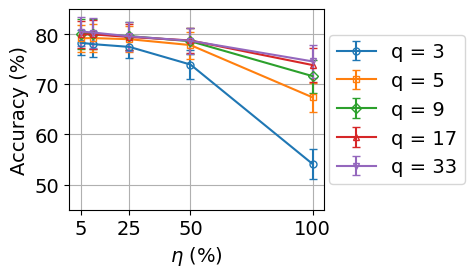

In [15]:
# again use the previously obtained df_unf here

# all-q plot for unfrozen == "all"
noise_levels = sorted(df_unf["x"].unique(), key=lambda v: 1.0 / v)
rsd_ticks = [100.0 / v for v in noise_levels]
nice_ticks = [t for t in rsd_ticks if t != 10]

fig, ax = plt.subplots(figsize=(5, 3))
plt.rcParams.update({"font.size": 14})

markers = ["o", "s", "D", "^", "v"]
i = -1

for q in sorted(df_unf["q"].unique()):
    sub = df_unf[(df_unf["q"] == q) & (df_unf["unfrozen"] == "all")].copy()

    xs_plot, mean_y, std_y = [], [], []
    for x in noise_levels:
        row = sub[sub["x"] == x].iloc[0]
        xs_plot.append(100.0 / x)
        mean_y.append(row["mean_acc"])
        std_y.append(row["std_acc"])

    xs_plot = np.array(xs_plot)
    mean_y  = np.array(mean_y)
    std_y   = np.array(std_y)

    i += 1
    marker = markers[i]

    ax.errorbar(xs_plot, mean_y, yerr=std_y, marker=marker, markerfacecolor="none", markersize=5, linewidth=1.5, capsize=3, label=f"q = {q+1}")

ax.set_xlabel(r"$\eta$ (%)")
ax.set_xticks(nice_ticks)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(45.0, 85.0)
ax.grid(True)

ax.legend(bbox_to_anchor=(1.02, 0.5), loc="center left", borderaxespad=0.0)

plt.tight_layout()
plt.savefig("../../results/figures/acc_vs_noise_alllayers_RSD_all_q.svg")
plt.show()
